In [1]:
import numpy as np
import matplotlib.pyplot as plt

from plots import *
from src import Transducer, covariance, log_negativity

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

# Microwave-optical entanglement

## Parameters

In [2]:
kappa_a = 13.2      # Optical linewidth [2π * GHz]
kappa_b = 0.002     # Microwave linewidth [2π * GHz]
omega_b = 5.0       # Microwave frequency [2π * GHz]
tau = 100.0         # Mode width [ns / 2π]

# Entanglement resonance (two-mode squeezing): Δ' = -ω_b'.
Delta = -omega_b

## Numerics

In [3]:
# Cooperativity.
C_list  = np.linspace(0.0, 0.999, 101)

# Detection efficiency pairs (eta_a, eta_b).
eta_pairs = [(1.0, 1.0), (0.78, 0.575)]

# Beam-splitter interaction relative strength z = g_t/g_s.
z_list = [0.0]

In [4]:
# Convert cooperativity to two-mode squeezing interaction strength.
g_s_list = np.sqrt(C_list * kappa_a * kappa_b)/2

# Calculate the entanglement generation rate.
ebit_rate = np.empty((len(C_list), len(eta_pairs), len(z_list)))
for i, g_s in enumerate(g_s_list):
    for j, (eta_a, eta_b) in enumerate(eta_pairs):
        transducer = Transducer(kappa_a, kappa_b, omega_b, Delta, eta_a, eta_b)
        for k, z in enumerate(z_list):
            V = covariance(transducer, z*g_s, g_s, tau)
            ebit_rate[i, j, k] = log_negativity(V) / tau

## Figure

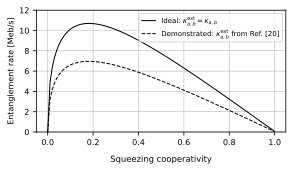

In [5]:
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1.2 * FIG_SIZES['onecol'],
        0.7 * FIG_SIZES['onecol']
        ),
    sharey = True,
    sharex = True,
    )

labels = [
    'Ideal: $\\kappa_{a,b}^{\\rm ext} = \\kappa_{a,b}$',
    'Demonstrated: $\\kappa_{a,b}^{\\rm ext}$ from Ref. [20]'
]

for j, etas in enumerate(eta_pairs):
    axs.plot(
        C_list, 
        ebit_rate[:, j, 0] * 2*np.pi * 1e3, 
        color = 'k',
        linewidth = 1, 
        linestyle = '-' if j == 0 else '--',
        label = labels[j]
        )

axs.grid('both')
axs.set_ylim(0, 12)

axs.set_ylabel("Entanglement rate [Meb/s]")
axs.legend()

fig.supxlabel('Squeezing cooperativity', x=0.55, y=0.04)
fig.tight_layout()
fig.savefig('fig/entanglement.pdf', bbox_inches='tight')